In [2]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
import random
from ISLP.models import (ModelSpec as MS, 
                         summarize)

In [3]:
random.seed(1234)

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)

fashion_df = fashion_df.fillna(0)

fashion_df.head()

,Shipping Address State,Revenue,Survey ResponseID,weather_category,ratio_cold_weather,ratio_fashion_accessories,ratio_hot_weather,ratio_indoor_basic,ratio_other,ratio_rain_protection,ppt,tmax,tmin,tavg
Order Date,,,,,,,,,,,,,,
2017-01-01,AL,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,25.626,13.849,4.712,9.280
2017-01-01,AR,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.999,10.667,4.430,7.548
2017-01-01,AZ,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,4.824,9.969,4.154,7.061
2017-01-01,CA,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,3.760,9.559,0.137,4.848
2017-01-01,CO,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.385,2.787,-9.496,-3.354


In [4]:
# Filter for one state 
# Arrange by date 
# Calc temp - temp(t=-365)
# Calc first oder difference in revenue
# for each state filter out days which were only used to calc temp-365 / meaning the day bevore revenue was recorded

In [5]:
df_one_state_filter = fashion_df["Shipping Address State"] == "CA"
df_one_state = fashion_df[df_one_state_filter].copy()

### Create 365 day laged temperature column

In [6]:
df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

### Create 365 laged rain column

In [7]:
df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

### Create first order diff for Revenue

In [8]:
first_order_diff = [0]

for j in range(1,len(df_one_state)): 
    first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])

df_one_state["first_order_diff_Revenue"] = first_order_diff
df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

C:\Users\morit\AppData\Local\Temp\ipykernel_14120\120880988.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])


### Lag first order diff for Revenue by 1 day

From testing with the autocorrelation we know that lagging the first order diff of revenue by 1 day is the best fit for our data    

In [9]:
df_one_state.loc[:, "first_order_diff_Revenue_lagged"] = df_one_state["first_order_diff_Revenue"].shift(-1)

## Test: Create a SMA 7 for Hot, Cold, Rain Clothing

In [10]:
df_one_state.loc[:, "SMA7_ratio_hot_weather_clothing"] = df_one_state["ratio_hot_weather"].rolling(7).mean().round(2)

df_one_state.loc[:, "SMA7_ratio_cold_weather_clothing"] = df_one_state["ratio_cold_weather"].rolling(7).mean().round(2)

df_one_state.loc[:, "SMA7_ratio_rain_weather_clothing"] = df_one_state["ratio_rain_protection"].rolling(7).mean().round(2)

### Remove days wich were only used for temp calculations

In [11]:
df_one_state = df_one_state.iloc[365:, :]

#### Linear regression for: First order difference Revenue ~ 365 lag Temp + 1 day lag first order difference Revenue

In [12]:
df_one_state.loc[:, 'Time'] = np.arange(len(df_one_state))

### Testing some Visualization

When comparing the Temperature change vs Previous Year against the 7 day laged first order difference from Revenue we can see that changes in the weather (positive and negative), result in a tick in revenue. Note: This observation is purley visual

In [13]:
"""df_one_state_plot = df_one_state.copy()
df_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)

df_one_state_plot = df_one_state.loc['2019-01-01':'2019-12-31']
df_one_state_plot = df_one_state_plot.reset_index()
# Plotting
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(df_one_state_plot["Order Date"],
            df_one_state_plot["Temp_No_Season"],
            color="tab:red")

# Second line

ax2 = ax1.twinx()
ax2.plot(df_one_state_plot["Order Date"],
         df_one_state_plot["first_order_diff_Revenue"],
         color="tab:blue")


# Decorations
# ax1 (left Y axis)
ax1.set_xlabel('Time', fontsize=20)
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel('Temperature change vs Previous Year', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )
ax1.grid(alpha=.4)

# ax2 (right Y axis)
ax2.set_ylabel("First order difference in Revenue", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
fig.tight_layout()
plt.show()

plt.show()"""

'df_one_state_plot = df_one_state.copy()\ndf_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)\n\ndf_one_state_plot = df_one_state.loc[\'2019-01-01\':\'2019-12-31\']\ndf_one_state_plot = df_one_state_plot.reset_index()\n# Plotting\nfig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)\n\n\nax1.plot(df_one_state_plot["Order Date"],\n            df_one_state_plot["Temp_No_Season"],\n            color="tab:red")\n\n# Second line\n\nax2 = ax1.twinx()\nax2.plot(df_one_state_plot["Order Date"],\n         df_one_state_plot["first_order_diff_Revenue"],\n         color="tab:blue")\n\n\n# Decorations\n# ax1 (left Y axis)\nax1.set_xlabel(\'Time\', fontsize=20)\nax1.tick_params(axis=\'x\', rotation=0, labelsize=12)\nax1.set_ylabel(\'Temperature change vs Previous Year\', color=\'tab:red\', fontsize=20)\nax1.tick_params(axis=\'y\', rotation=0, labelcolor=\'tab:red\' )\nax1.grid(alpha=.4)\n\n# ax2 (right Y axis)\nax2.set_ylabel("First order difference

## Linear Regression for Revenue

In [14]:

import statsmodels.api as sm
df_one_state = df_one_state.fillna(0)

x = df_one_state[["Time", "Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt"]]
y = df_one_state['Revenue']
model = sm.OLS(y, sm.add_constant(x))
results = model.fit()
#print(results.params)
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     307.6
Date:                Mon, 03 Feb 2025   Prob (F-statistic):          1.30e-275
Time:                        16:33:09   Log-Likelihood:                -11612.
No. Observations:                1905   AIC:                         2.324e+04
Df Residuals:                    1898   BIC:                         2.328e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## Linear Regression first order difference Revenue

In [15]:
y = df_one_state["first_order_diff_Revenue"]
X = MS(["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"]).fit_transform(df_one_state)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())


                               OLS Regression Results                               
Dep. Variable:     first_order_diff_Revenue   R-squared:                       0.239
Model:                                  OLS   Adj. R-squared:                  0.237
Method:                       Least Squares   F-statistic:                     99.42
Date:                      Mon, 03 Feb 2025   Prob (F-statistic):          5.95e-109
Time:                              16:33:09   Log-Likelihood:                -12410.
No. Observations:                      1905   AIC:                         2.483e+04
Df Residuals:                          1898   BIC:                         2.487e+04
Df Model:                                 6                                         
Covariance Type:                  nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

## Linear regression with design matrix for SMA ratio hot, cold, rain weather

#### Linear Regression SMA7 Hot Weather Clothing

In [16]:


y = df_one_state["SMA7_ratio_hot_weather_clothing"]
X = MS(["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"]).fit_transform(df_one_state)

model = sm.OLS(y, X)
results = model.fit()

print(f"Linear Regression for SMA7_ratio_hot_weather_clothing: \n {results.summary()}")

Linear Regression for SMA7_ratio_hot_weather_clothing: 
                                    OLS Regression Results                                  
Dep. Variable:     SMA7_ratio_hot_weather_clothing   R-squared:                       0.188
Model:                                         OLS   Adj. R-squared:                  0.185
Method:                              Least Squares   F-statistic:                     73.03
Date:                             Mon, 03 Feb 2025   Prob (F-statistic):           3.92e-82
Time:                                     16:33:09   Log-Likelihood:                 2247.0
No. Observations:                             1905   AIC:                            -4480.
Df Residuals:                                 1898   BIC:                            -4441.
Df Model:                                        6                                         
Covariance Type:                         nonrobust                                         
                       

##### Test with lagging the SMA7 ration by additional 23 days

In [17]:
y = df_one_state["SMA7_ratio_hot_weather_clothing"].shift(39).fillna(0)
# Test with different shifts
# 53: 0,316
# 43: 0,327
# 40: 0,327
# 38: 0,329
# 33: 0,314
X = MS(["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"]).fit_transform(df_one_state)

model = sm.OLS(y, X)
results = model.fit()

print(f"Linear Regression for SMA7_ratio_hot_weather_clothing: \n {results.summary()}")

Linear Regression for SMA7_ratio_hot_weather_clothing: 
                                    OLS Regression Results                                  
Dep. Variable:     SMA7_ratio_hot_weather_clothing   R-squared:                       0.329
Model:                                         OLS   Adj. R-squared:                  0.327
Method:                              Least Squares   F-statistic:                     154.9
Date:                             Mon, 03 Feb 2025   Prob (F-statistic):          2.73e-160
Time:                                     16:33:09   Log-Likelihood:                 2413.9
No. Observations:                             1905   AIC:                            -4814.
Df Residuals:                                 1898   BIC:                            -4775.
Df Model:                                        6                                         
Covariance Type:                         nonrobust                                         
                       

#### Linear Regression SMA7 Ratio Cold Weather

In [18]:
y = df_one_state["SMA7_ratio_cold_weather_clothing"].shift(23).fillna(0)
#y = df_one_state["SMA7_ratio_cold_weather_clothing"]
model = sm.OLS(y, X)
results = model.fit()

print(f"\n\nLinear Regression for SMA7_ratio_cold_weather_clothing: \n {results.summary()}")



Linear Regression for SMA7_ratio_cold_weather_clothing: 
                                    OLS Regression Results                                   
Dep. Variable:     SMA7_ratio_cold_weather_clothing   R-squared:                       0.087
Model:                                          OLS   Adj. R-squared:                  0.084
Method:                               Least Squares   F-statistic:                     30.17
Date:                              Mon, 03 Feb 2025   Prob (F-statistic):           1.01e-34
Time:                                      16:33:09   Log-Likelihood:                 2814.0
No. Observations:                              1905   AIC:                            -5614.
Df Residuals:                                  1898   BIC:                            -5575.
Df Model:                                         6                                         
Covariance Type:                          nonrobust                                         
          

#### Linear Regression SMA7 Ratio Rain Weather Clothing

In [19]:
#y = df_one_state["SMA7_ratio_rain_weather_clothing"].shift(23).fillna(0) # If we add the shift here R^2 decreases
y = df_one_state["SMA7_ratio_rain_weather_clothing"]
model = sm.OLS(y, X)
results = model.fit()

print(f"\n\n Linear Regression for SMA7_ratio_rain_weather_clothing: \n {results.summary()}")



 Linear Regression for SMA7_ratio_rain_weather_clothing: 
                                    OLS Regression Results                                   
Dep. Variable:     SMA7_ratio_rain_weather_clothing   R-squared:                       0.044
Model:                                          OLS   Adj. R-squared:                  0.041
Method:                               Least Squares   F-statistic:                     14.43
Date:                              Mon, 03 Feb 2025   Prob (F-statistic):           3.73e-16
Time:                                      16:33:09   Log-Likelihood:                 1795.3
No. Observations:                              1905   AIC:                            -3577.
Df Residuals:                                  1898   BIC:                            -3538.
Df Model:                                         6                                         
Covariance Type:                          nonrobust                                         
         

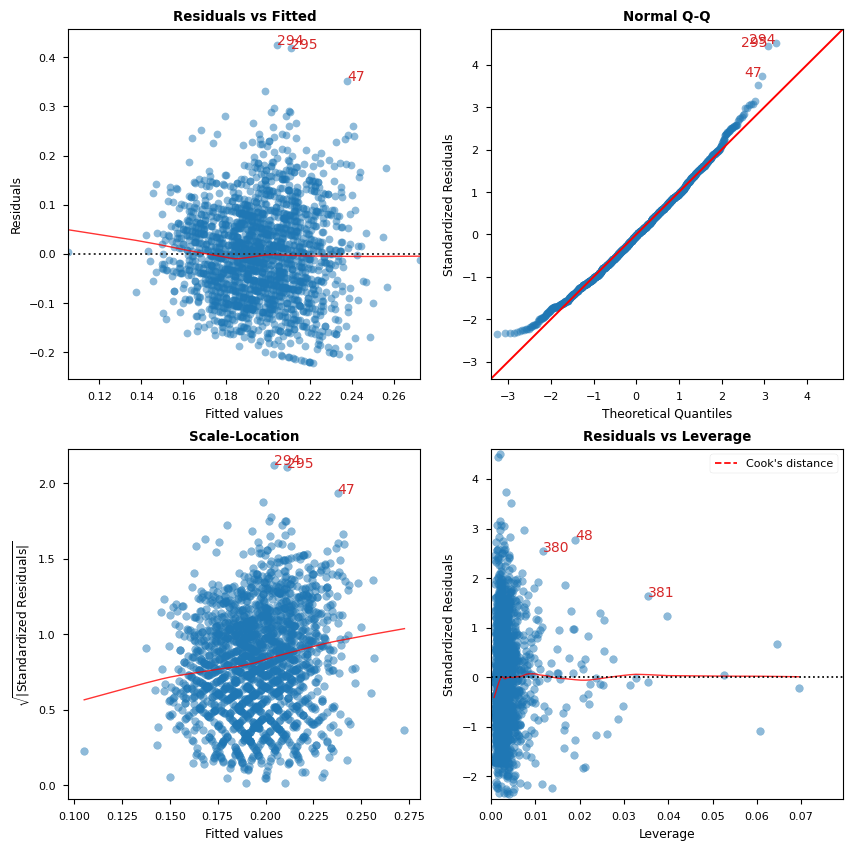

                          Features  VIF Factor
3  first_order_diff_Revenue_lagged        1.00
6                             Time        1.02
1                   Temp_No_Season        1.15
4                             tavg        1.37
2                   Rain_No_Season        2.08
5                              ppt        2.27
0                        intercept       11.65


In [20]:
from utils.Lin_reg_plotting import LinearRegDiagnostic
 
cls = LinearRegDiagnostic(results)

vif, fig, ax = cls()
print(vif)

From this model we see that nether rain nor temperature have a statiscally signifcant impact on our prediction of revenue

In [21]:
df_one_state_regression = df_one_state.copy()


x = df_one_state[["Temp_No_Season"]]
y = df_one_state["SMA7_ratio_cold_weather_clothing"]
model = sm.OLS(y, sm.add_constant(x))
results = model.fit()
#print(results.params)
print(results.summary())


                                   OLS Regression Results                                   
Dep. Variable:     SMA7_ratio_cold_weather_clothing   R-squared:                       0.001
Model:                                          OLS   Adj. R-squared:                  0.001
Method:                               Least Squares   F-statistic:                     1.970
Date:                              Mon, 03 Feb 2025   Prob (F-statistic):              0.161
Time:                                      16:33:11   Log-Likelihood:                 2726.5
No. Observations:                              1905   AIC:                            -5449.
Df Residuals:                                  1903   BIC:                            -5438.
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                     coef    std err          t      P>|t|      [0.025

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_one_state_plot = df_one_state.copy()
df_one_state_plot = df_one_state_plot.reset_index()
#df_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)


# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add temperature line
fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["tavg"],
        name="Averrage Temp",
        line=dict(color="red")
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["Temp_No_Season"],
        name="Temp_No_Season",
        line=dict(color="green")
    ),
    secondary_y=False
)


# Add revenue line
fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["SMA7_ratio_hot_weather_clothing"].shift(39),
        name="SMA7 Ratio hot weather clothing",
        line=dict(color="blue")
    ),
    secondary_y=True
)

fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["SMA7_ratio_cold_weather_clothing"].shift(39),
        name="SMA7 Ratio cold weather clothing",
        line=dict(color="yellow")
    ),
    secondary_y=True
)

# Update layout
fig.update_layout(
    title="Temperature and Revenue Change Over Time",
    xaxis_title="Order Date",
    width=1200,
    height=600
)

# Update y-axes labels
#fig.update_yaxes(title_text="Temperature", secondary_y=False)
#fig.update_yaxes(title_text="Revenue Change", secondary_y=True)

# Show the plot
fig.show()

c:\Users\morit\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [23]:
"""df_one_state_plot = df_one_state.copy()
df_one_state_plot = df_one_state_plot.reset_index()
#df_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)


# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["tavg"],
        name="Averrage Temp",
        line=dict(color="red")
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["Temp_No_Season"].rolling(14).mean().round(2),
        name="Temp_No_Season",
        line=dict(color="green")
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["ratio_indoor_basic"].rolling(30).mean().round(2),
        name="SMA7 Ratio cold weather clothing",
        line=dict(color="blue")
    ),
    secondary_y=True
)

# Update layout
fig.update_layout(
    title="Temperature and Revenue Change Over Time",
    xaxis_title="Order Date",
    width=1200,
    height=600
)

# Update y-axes labels
#fig.update_yaxes(title_text="Temperature", secondary_y=False)
#fig.update_yaxes(title_text="Revenue Change", secondary_y=True)

# Show the plot
fig.show()"""

'df_one_state_plot = df_one_state.copy()\ndf_one_state_plot = df_one_state_plot.reset_index()\n#df_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)\n\n\n# Create figure with secondary y-axis\nfig = make_subplots(specs=[[{"secondary_y": True}]])\n\nfig.add_trace(\n    go.Scatter(\n        x=df_one_state_plot["Order Date"],\n        y=df_one_state_plot["tavg"],\n        name="Averrage Temp",\n        line=dict(color="red")\n    ),\n    secondary_y=False\n)\n\nfig.add_trace(\n    go.Scatter(\n        x=df_one_state_plot["Order Date"],\n        y=df_one_state_plot["Temp_No_Season"].rolling(14).mean().round(2),\n        name="Temp_No_Season",\n        line=dict(color="green")\n    ),\n    secondary_y=False\n)\n\nfig.add_trace(\n    go.Scatter(\n        x=df_one_state_plot["Order Date"],\n        y=df_one_state_plot["ratio_indoor_basic"].rolling(30).mean().round(2),\n        name="SMA7 Ratio cold weather clothing",\n        line=dict(color="

# Linear Regression with sub categories

### Calc first order diff of Hot weather clothing sales

In [24]:
from utils.linear_reg_fun import linear_regresion_per_state

linear_reg2 = linear_regresion_per_state(fashion_df, y_input="first_order_diff_Revenue", X_input=["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"])

    Info Model Fit         Coefficients  P-values Coefficients P-values  \
   State       R^2 R^2 Adj    intercept intercept         Time     Time   
0     AL     0.028   0.027        9.981     0.000        0.013    0.000   
1     AR     0.027   0.026        6.486     0.000        0.010    0.000   
2     AZ     0.036   0.035       14.742     0.000        0.017    0.000   
3     CA     0.103   0.102      109.767     0.000        0.088    0.000   
4     CO     0.017   0.016       21.005     0.000        0.013    0.000   
5     CT     0.009   0.008       14.967     0.000        0.009    0.000   
6     DE     0.015   0.014        4.292     0.000        0.006    0.000   
7     FL     0.167   0.166       45.769     0.000        0.092    0.000   
8     GA     0.084   0.083       19.499     0.000        0.038    0.000   
9     IA     0.017   0.016        9.632     0.000        0.007    0.000   
10    ID     0.017   0.016        2.479     0.011        0.005    0.000   
11    IL     0.071   0.07

In [25]:
linear_reg2.head()

Info Model Fit         Coefficients  P-values   Coefficients  \
  State       R^2 R^2 Adj    intercept intercept Temp_No_Season   
0    AL     0.255   0.253        1.394     0.710         -0.037   
1    AR     0.253   0.250       -0.635     0.807         -0.006   
2    AZ     0.266   0.264       -0.056     0.988         -0.096   
3    CA     0.239   0.237       -0.620     0.961          0.059   
4    CO     0.234   0.231        0.251     0.943          0.144   

        P-values   Coefficients       P-values  \
  Temp_No_Season Rain_No_Season Rain_No_Season   
0          0.872         -0.031          0.825   
1          0.972         -0.154          0.163   
2          0.766          0.255          0.716   
3          0.951         -0.036          0.972   
4          0.634          0.521          0.526   

                     Coefficients                        P-values  \
  first_order_diff_Revenue_lagged first_order_diff_Revenue_lagged   
0                          -0.504                             0.0   
1                          -0.503                             0.0   
2                          -0.516                             0.0   
3                          -0.489                             0.0   
4                          -0.483                             0.0   

  Coefficients P-values Coefficients P-values Coefficients P-values  
          tavg     tavg          ppt      ppt         Time     Time  
0       -0.008    0.957       -0.246    0.210       -0.000    0.956  
1        0.001    0.990        0.153    0.313       -0.000    0.986  
2        0.012    0.940        0.003    0.998       -0.000    0.936  
3        0.083    0.889        0.115    0.936       -0.001    0.905  
4        0.084    0.603       -0.550    0.631       -0.000    0.944